# Tokenization Playground for Multilingual NLP (ES / EN / FR)

This notebook explores and compares different tokenization strategies across **Spanish**, **English**, and **French**, and demonstrates a reusable **PyTorch data pipeline** for NLP preprocessing.

## Why tokenization matters
Tokenization is a foundational step in NLP and LLM pipelines. It determines how raw text is split into units (characters, words, subwords), which affects:
- vocabulary size
- sequence length
- memory usage
- model performance
- multilingual robustness

## Objectives
- Compare tokenizers: **character**, **word**, **spaCy**, and **WordPiece (Hugging Face)**
- Analyze token counts and observed vocabulary behavior across ES/EN/FR
- Build a reusable data pipeline: **load → vocab → collate → DataLoader**
- Prepare batches ready for PyTorch training

## Stack
- **PyTorch**
- **pandas**
- **spaCy**
- **Hugging Face Transformers**

In [1]:
!pip install torch pandas spacy transformers src

  Using cached src-0.0.7.zip (6.3 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Running setup.py clean for src
Failed to build src


  DEPRECATION: Building 'src' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'src'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> [88 lines of output]
      C:\Users\rafae\anaconda3\Lib\site-packages\setuptools\_distutils\dist.py:268: UserWarning: Unknown distribution option: 'tests_require'
        warnings.warn(msg)
      running bdist_wheel
      running build
      running build_py
      creating build
      creating build\lib
      creating build\lib\src
      copying src\__init__.py -> build\lib\src
      running egg_info
      writing src.egg-in

In [2]:
!python -m spacy download es_core_news_sm
!python -m spacy download en_core_web_sm
!python -m spacy download fr_core_news_sm

     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
     ---- ----------------------------------- 1.6/12.9 MB 10.1 MB/s eta 0:00:02
     --------- ------------------------------ 3.1/12.9 MB 8.7 MB/s eta 0:00:02
     ---------------- ----------------------- 5.2/12.9 MB 9.5 MB/s eta 0:00:01
     ----------------------- ---------------- 7.6/12.9 MB 9.9 MB/s eta 0:00:01
     --------------------------- ------------ 8.9/12.9 MB 9.5 MB/s eta 0:00:01
     --------------------------------- ------ 10.7/12.9 MB 9.4 MB/s eta 0:00:01
     ------------------------------------- -- 12.1/12.9 MB 8.7 MB/s eta 0:00:01
     ---------------------------------------  12.8/12.9 MB 8.6 MB/s eta 0:00:01
     ---------------------------------------- 12.9/12.9 MB 7.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     --- -----------------------------

In [3]:
import sys
from pathlib import Path

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

print("CWD:", cwd)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("Exists src?:", (PROJECT_ROOT / "src").exists())

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("sys.path[0]:", sys.path[0])

CWD: c:\Users\rafae\Desktop\LLM_practices\tokenization_playgroud\notebooks
PROJECT_ROOT: c:\Users\rafae\Desktop\LLM_practices\tokenization_playgroud
Exists src?: True
sys.path[0]: c:\Users\rafae\Desktop\LLM_practices\tokenization_playgroud


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Optional display settings
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 200)

# Reproducibility (if using torch in notebook)
try:
    import torch
    torch.manual_seed(42)
except Exception:
    pass


In [5]:
from src.config import SAMPLE_ES, SAMPLE_EN, SAMPLE_FR, BATCH_SIZE, SPACY_MODELS, HF_MODEL_NAME
from src.pipelines.pipeline_tokenizer import DataPipeline, TokenizerEvalPipeline

from src.tokenizers.char_tokenizer import CharTokenizer
from src.tokenizers.word_tokenizer import WordTokenizer
from src.tokenizers.spacy_tokenizer import SpacyTokenizer
from src.tokenizers.hf_wordpiece_tokenizer import HFWordpieceTokenizer

## 1. Data loading
We load sample text files (one sentence per line) for each language and inspect the dataset sizes.

In [6]:
paths_by_lang = {
    "es": SAMPLE_ES,
    "en": SAMPLE_EN,
    "fr": SAMPLE_FR,
}

tmp_pipeline = DataPipeline(
    paths_by_lang=paths_by_lang,
    tokenize_fn=lambda x: x.strip().split()
).load()

samples_by_lang = tmp_pipeline.texts_by_lang
all_texts = tmp_pipeline.all_texts

for lang, texts in samples_by_lang.items():
    print(f"{lang}: {len(texts)} lines")
    if texts:
        print("  sample:", texts[0])

es: 4 lines
  sample: Me gusta aprender inteligencia artificial porque me ayuda a resolver problemas reales.
en: 4 lines
  sample: I enjoy learning artificial intelligence because it helps me solve real problems.
fr: 4 lines
  sample: J'aime apprendre l'intelligence artificielle parce qu'elle m'aide à résoudre des problèmes réels.


## 2. Tokenizer comparison (char / word / spaCy / WordPiece)

We build a tokenizer registry and compare them using:
- average number of tokens per text
- min/max tokens
- observed vocabulary size
- tokenizer vocabulary size (when available)

In [7]:
# Build a word tokenizer from the full multilingual corpus
word_tokenizer = WordTokenizer.from_corpus(all_texts)

tokenizers = {
    "char": CharTokenizer(),
    "word": word_tokenizer,
}

# spaCy tokenizers (language-specific)
for lang, model_name in SPACY_MODELS.items():
    try:
        tokenizers[f"spacy_{lang}"] = SpacyTokenizer(model_name)
    except Exception as e:
        print(f"[WARN] Could not load spacy_{lang}: {e}")

# Hugging Face subword tokenizer (WordPiece / multilingual BERT)
try:
    tokenizers["hf_wordpiece"] = HFWordpieceTokenizer(HF_MODEL_NAME)
except Exception as e:
    print(f"[WARN] Could not load HF tokenizer: {e}")

list(tokenizers.keys())

['char', 'word', 'spacy_es', 'spacy_en', 'spacy_fr', 'hf_wordpiece']

In [8]:
# Build a word tokenizer from the full multilingual corpus
word_tokenizer = WordTokenizer.from_corpus(all_texts)

tokenizers = {
    "char": CharTokenizer(),
    "word": word_tokenizer,
}

# spaCy tokenizers (language-specific)
for lang, model_name in SPACY_MODELS.items():
    try:
        tokenizers[f"spacy_{lang}"] = SpacyTokenizer(model_name)
    except Exception as e:
        print(f"[WARN] Could not load spacy_{lang}: {e}")

# Hugging Face subword tokenizer (WordPiece / multilingual BERT)
try:
    tokenizers["hf_wordpiece"] = HFWordpieceTokenizer(HF_MODEL_NAME)
except Exception as e:
    print(f"[WARN] Could not load HF tokenizer: {e}")

list(tokenizers.keys())

['char', 'word', 'spacy_es', 'spacy_en', 'spacy_fr', 'hf_wordpiece']

In [9]:
# Build evaluation pipeline from tokenizers and loaded samples
eval_pipeline = TokenizerEvalPipeline(tokenizers, samples_by_lang)
df_summary = eval_pipeline.summarize()
df_examples = eval_pipeline.examples(max_samples=1)

# Show the most relevant columns
df_examples[["language", "tokenizer", "n_tokens", "tokens"]]

,language,tokenizer,n_tokens,tokens
0,es,char,86,"[M, e, , g, u, s, t, a, , a, p, r, e, n, d, e, r, , i, n, t, e, l, i, g, e, n, c, i, a, , a, r, t, i, f, i, c, i..."
1,es,word,12,"[Me, gusta, aprender, inteligencia, artificial, porque, me, ayuda, a, resolver, problemas, reales.]"
2,es,spacy_es,13,"[Me, gusta, aprender, inteligencia, artificial, porque, me, ayuda, a, resolver, problemas, reales, .]"
3,es,spacy_en,13,"[Me, gusta, aprender, inteligencia, artificial, porque, me, ayuda, a, resolver, problemas, reales, .]"
4,es,spacy_fr,13,"[Me, gusta, aprender, inteligencia, artificial, porque, me, ayuda, a, resolver, problemas, reales, .]"
5,es,hf_wordpiece,15,"[Me, gu, ##sta, aprender, intel, ##igencia, artificial, porque, me, ayuda, a, resolver, problemas, reales, .]"
6,en,char,81,"[I, , e, n, j, o, y, , l, e, a, r, n, i, n, g, , a, r, t, i, f, i, c, i, a, l, , i, n, t, e, l, l, i, g, e, n, c..."
7,en,word,12,"[I, enjoy, learning, artificial, intelligence, because, it, helps, me, solve, real, problems.]"
8,en,spacy_es,13,"[I, enjoy, learning, artificial, intelligence, because, it, helps, me, solve, real, problems, .]"
9,en,spacy_en,13,"[I, enjoy, learning, artificial, intelligence, because, it, helps, me, solve, real, problems, .]"


## 2.1 Quick visualization
A simple comparison of average token counts by tokenizer and language.

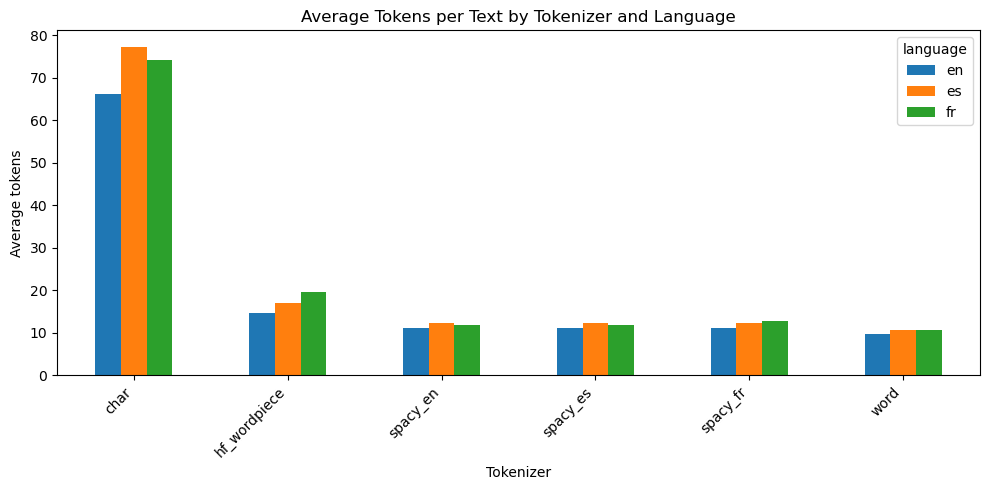

In [10]:
plot_df = df_summary.dropna(subset=["avg_tokens"]).copy()

if not plot_df.empty:
    pivot_df = plot_df.pivot(index="tokenizer", columns="language", values="avg_tokens")
    pivot_df.plot(kind="bar", figsize=(10, 5))
    plt.title("Average Tokens per Text by Tokenizer and Language")
    plt.xlabel("Tokenizer")
    plt.ylabel("Average tokens")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No data available for plotting.")

## 3. Reusable PyTorch data pipeline (vocab + DataLoader)

Now we use the project pipeline to build:
- vocabulary (`stoi`, `itos`)
- padded batches via `collate_fn`
- a `DataLoader` ready for model training

In [11]:
# Final data pipeline using the word tokenizer
data_pipeline = DataPipeline(
    paths_by_lang=paths_by_lang,
    tokenize_fn=word_tokenizer.tokenize,
    batch_size=BATCH_SIZE,
    shuffle=True,
).load().build_vocab(min_freq=1)

print("Total texts:", len(data_pipeline.all_texts))
print("Vocab size:", len(data_pipeline.stoi))
print("stoi preview:", dict(list(data_pipeline.stoi.items())[:12]))

Total texts: 12
Vocab size: 113
stoi preview: {'<pad>': 0, '<unk>': 1, '<bos>': 2, '<eos>': 3, 'Me': 4, 'gusta': 5, 'aprender': 6, 'inteligencia': 7, 'artificial': 8, 'porque': 9, 'me': 10, 'ayuda': 11}


In [12]:
texts_es = data_pipeline.texts_by_lang["es"]
labels_es = [1 if i % 2 == 0 else 0 for i in range(len(texts_es))]  # dummy labels for demo

loader_es = data_pipeline.get_loader(lang="es", labels=labels_es)

batch_x, batch_y = next(iter(loader_es))

print("Batch X shape:", batch_x.shape)
print("Batch Y shape:", batch_y.shape)
print("\nBatch X (token ids):")
print(batch_x)
print("\nBatch Y (labels):")
print(batch_y)

Batch X shape: torch.Size([4, 14])
Batch Y shape: torch.Size([4])

Batch X (token ids):
tensor([[ 2,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,  3],
        [ 2, 28, 29, 19, 30, 22, 31, 32, 33, 34,  3,  0,  0,  0],
        [ 2, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44,  3,  0,  0],
        [ 2, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27,  3]])

Batch Y (labels):
tensor([1, 1, 0, 0])


In [13]:
itos = data_pipeline.itos
first_seq_ids = batch_x[0].tolist()
decoded_tokens = [itos[i] for i in first_seq_ids]

print("Decoded token sequence (first text):")
print(decoded_tokens)

Decoded token sequence (first text):
['<bos>', 'Me', 'gusta', 'aprender', 'inteligencia', 'artificial', 'porque', 'me', 'ayuda', 'a', 'resolver', 'problemas', 'reales.', '<eos>']


## 4. Observations

### Tokenization behavior
- **Character tokenization** produces longer sequences but a smaller observed vocabulary.
- **Word tokenization** keeps semantic units intact but grows vocabulary quickly.
- **spaCy tokenization** handles punctuation and language-specific rules better than naive word splitting.
- **WordPiece (HF)** often splits rare/complex words into subword pieces, reducing OOV issues.

### Multilingual considerations
- French contractions and apostrophes (e.g., *l'intelligence*) highlight tokenizer differences clearly.
- Spanish accents and punctuation (¿, ¡) are useful stress tests for character/word tokenizers.
- Subword tokenization is especially useful for multilingual or low-resource settings.

## 5. Conclusion and next steps

This notebook demonstrates a modular multilingual tokenization playground and a reusable PyTorch preprocessing pipeline.

### What is already implemented
- tokenizer comparison across ES / EN / FR
- reusable `DataPipeline` (load + vocab + DataLoader)
- tokenizer evaluation pipeline (`summary` + `examples`)
- batch generation with padding for PyTorch

### Next improvements
- Add **German** (`sample_de.txt`) for a 4-language comparison
- Add **RegexWordTokenizer** to improve baseline word tokenization
- Export summary/examples to CSV for reporting
- Add a small **language identification** model with character n-grams
- Build a **Streamlit UI** for interactive tokenizer exploration